In [1]:
import fastf1
from matplotlib import pyplot as plt
from fastf1 import plotting
import seaborn as sns

In [2]:
session = fastf1.get_session(2019, 12, 'R')
session.name
session.date

session.load()

req         WARNING 	DEFAULT CACHE ENABLED! (77.63 MB) C:\Users\pavel\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 44 completed the race distance 00:00.069000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '33', '5', '16', '55', '10', '7', '77', '4', '23', '11', '

In [3]:
session.results.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [4]:
df = session.results[['BroadcastName', 'Abbreviation', 'DriverNumber', 'TeamName', 'CountryCode', 'GridPosition', 'Position', 'ClassifiedPosition', 'Time', 'Points', 'Status']]
df.head()

,BroadcastName,Abbreviation,DriverNumber,TeamName,CountryCode,GridPosition,Position,ClassifiedPosition,Time,Points,Status
44,L HAMILTON,HAM,44,Mercedes,,3.0,1.0,1,0 days 01:35:03.796000,25.0,Finished
33,M VERSTAPPEN,VER,33,Red Bull Racing,,1.0,2.0,2,0 days 00:00:17.796000,19.0,Finished
5,S VETTEL,VET,5,Ferrari,,5.0,3.0,3,0 days 00:01:01.433000,15.0,Finished
16,C LECLERC,LEC,16,Ferrari,,4.0,4.0,4,0 days 00:01:05.250000,12.0,Finished
55,C SAINZ,SAI,55,McLaren,,8.0,5.0,5,NaT,10.0,+1 Lap


Lap times 

req            INFO 	Using cached data for driver_info


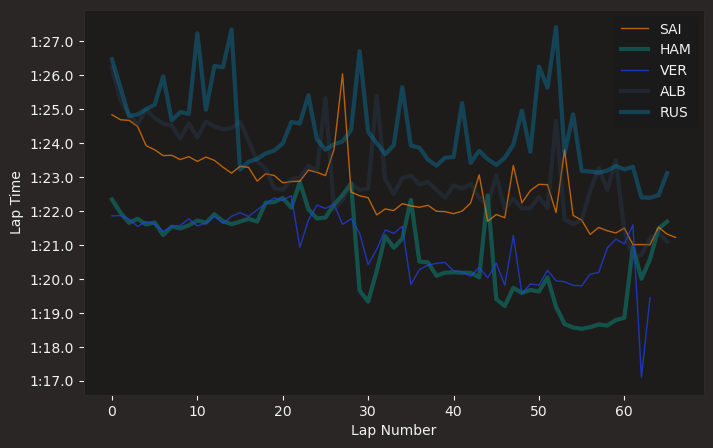

In [5]:
my_styles = [
    # style for each first driver
    {'color': 'auto', 'linestyle': 'solid', 'linewidth': 3, 'alpha': 0.3},
    # style for each second driver
    {'color': 'auto', 'linestyle': 'solid', 'linewidth': 1, 'alpha': 0.7}
]

fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

fig, ax = plt.subplots(figsize=(8, 5))

for driver in ('HAM', 'SAI', 'VER', 'ALB', 'RUS'):
    laps = session.laps.pick_drivers(driver).pick_quicklaps().reset_index()
    style = plotting.get_driver_style(identifier=driver,
                                      style=my_styles,
                                      session=session)
    ax.plot(laps['LapTime'], **style, label=driver)

# add axis labels and a legend
ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
plotting.add_sorted_driver_legend(ax, session)

Laptimes Scatterplot

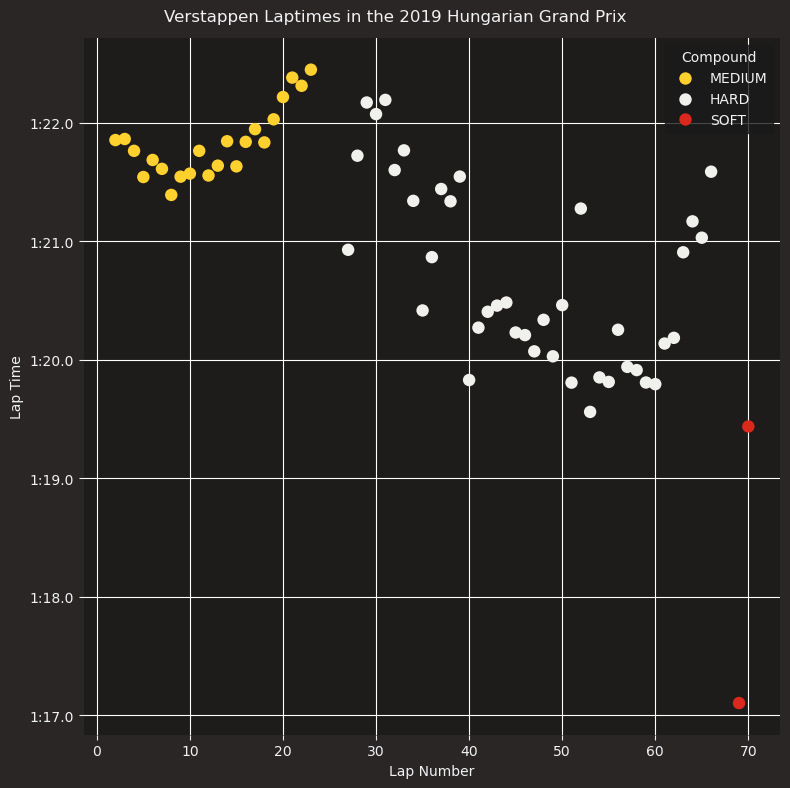

In [6]:
# Enable Matplotlib patches for plotting timedelta values and load
# FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

#Pick driver
driver_laps = session.laps.pick_drivers("VER").pick_quicklaps().reset_index()

# Get driver-info
driver = "VER"
driver_info = session.get_driver(driver)
last_name = driver_info['LastName']

# Get event-info 
year = session.event.year
gp_name = session.event.EventName

#Make the figure
fig, ax = plt.subplots(figsize=(8, 8))

#Plot the data
sns.scatterplot(data=driver_laps,
                x="LapNumber",
                y="LapTime",
                ax=ax,
                hue="Compound",
                palette=fastf1.plotting.get_compound_mapping(session=session),
                s=80,
                linewidth=0,
                legend='auto')

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")

# The y-axis increases from bottom to top by default
# Since we are plotting time, it makes sense to invert the axis
ax.invert_yaxis()
plt.suptitle(f"{last_name} Laptimes in the {year} {gp_name}")

# Turn on major grid lines
plt.grid(color='w', which='major', axis='both')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

Missing values detection

In [7]:
df.isna()

,BroadcastName,Abbreviation,DriverNumber,TeamName,CountryCode,GridPosition,Position,ClassifiedPosition,Time,Points,Status
44,False,False,False,False,False,False,False,False,False,False,False
33,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False
16,False,False,False,False,False,False,False,False,False,False,False
55,False,False,False,False,False,False,False,False,True,False,False
10,False,False,False,False,False,False,False,False,True,False,False
7,False,False,False,False,False,False,False,False,True,False,False
77,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,True,False,False
23,False,False,False,False,False,False,False,False,True,False,False


In [8]:
df['Time']

44   0 days 01:35:03.796000
33   0 days 00:00:17.796000
5    0 days 00:01:01.433000
16   0 days 00:01:05.250000
55                      NaT
10                      NaT
7                       NaT
77                      NaT
4                       NaT
23                      NaT
11                      NaT
27                      NaT
20                      NaT
3                       NaT
26                      NaT
63                      NaT
18                      NaT
99                      NaT
88                      NaT
8                       NaT
Name: Time, dtype: timedelta64[ns]

NaT time = Lapped riders

In [9]:
df.fillna('Lapped')

,BroadcastName,Abbreviation,DriverNumber,TeamName,CountryCode,GridPosition,Position,ClassifiedPosition,Time,Points,Status
44,L HAMILTON,HAM,44,Mercedes,,3.0,1.0,1,0 days 01:35:03.796000,25.0,Finished
33,M VERSTAPPEN,VER,33,Red Bull Racing,,1.0,2.0,2,0 days 00:00:17.796000,19.0,Finished
5,S VETTEL,VET,5,Ferrari,,5.0,3.0,3,0 days 00:01:01.433000,15.0,Finished
16,C LECLERC,LEC,16,Ferrari,,4.0,4.0,4,0 days 00:01:05.250000,12.0,Finished
55,C SAINZ,SAI,55,McLaren,,8.0,5.0,5,Lapped,10.0,+1 Lap
10,P GASLY,GAS,10,Red Bull Racing,,6.0,6.0,6,Lapped,8.0,+1 Lap
7,K RAIKKONEN,RAI,7,Alfa Romeo Racing,,10.0,7.0,7,Lapped,6.0,+1 Lap
77,V BOTTAS,BOT,77,Mercedes,,2.0,8.0,8,Lapped,4.0,+1 Lap
4,L NORRIS,NOR,4,McLaren,,7.0,9.0,9,Lapped,2.0,+1 Lap
23,A ALBON,ALB,23,Toro Rosso,,12.0,10.0,10,Lapped,1.0,+1 Lap


In [10]:
session.laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [11]:
df_laps = session.laps[['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'Compound', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife','Position']]
df_laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Compound,SpeedI1,SpeedI2,SpeedFL,SpeedST,TyreLife,Position
0,0 days 00:34:16.691000,HAM,44,0 days 00:01:27.403000,1.0,1.0,MEDIUM,275.0,238.0,249.0,250.0,4.0,2.0
1,0 days 00:35:39.026000,HAM,44,0 days 00:01:22.335000,2.0,1.0,MEDIUM,273.0,239.0,248.0,288.0,5.0,2.0
2,0 days 00:37:00.972000,HAM,44,0 days 00:01:21.946000,3.0,1.0,MEDIUM,274.0,239.0,247.0,282.0,6.0,2.0
3,0 days 00:38:22.618000,HAM,44,0 days 00:01:21.646000,4.0,1.0,MEDIUM,271.0,241.0,247.0,282.0,7.0,2.0
4,0 days 00:39:44.385000,HAM,44,0 days 00:01:21.767000,5.0,1.0,MEDIUM,273.0,239.0,247.0,287.0,8.0,2.0


C:\Users\pavel\AppData\Local\Temp\ipykernel_16824\707099359.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_laps['LapTimeSeconds'] = laptime.dt.total_seconds()


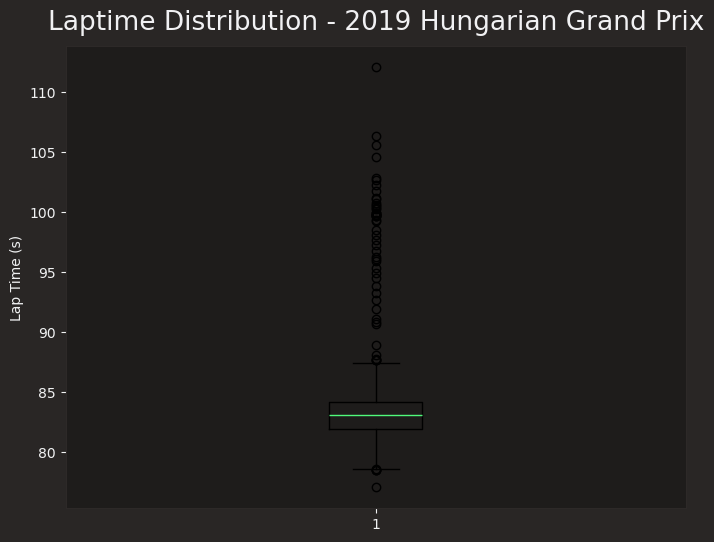

In [12]:
laptime = df_laps['LapTime']

df_laps['LapTimeSeconds'] = laptime.dt.total_seconds()

plt.figure(figsize=(8, 6))
plt.boxplot(df_laps["LapTimeSeconds"].dropna(), vert=True)

plt.ylabel("Lap Time (s)")
plt.title(f"Laptime Distribution - {session.event.year} {session.event.EventName}")

plt.show()

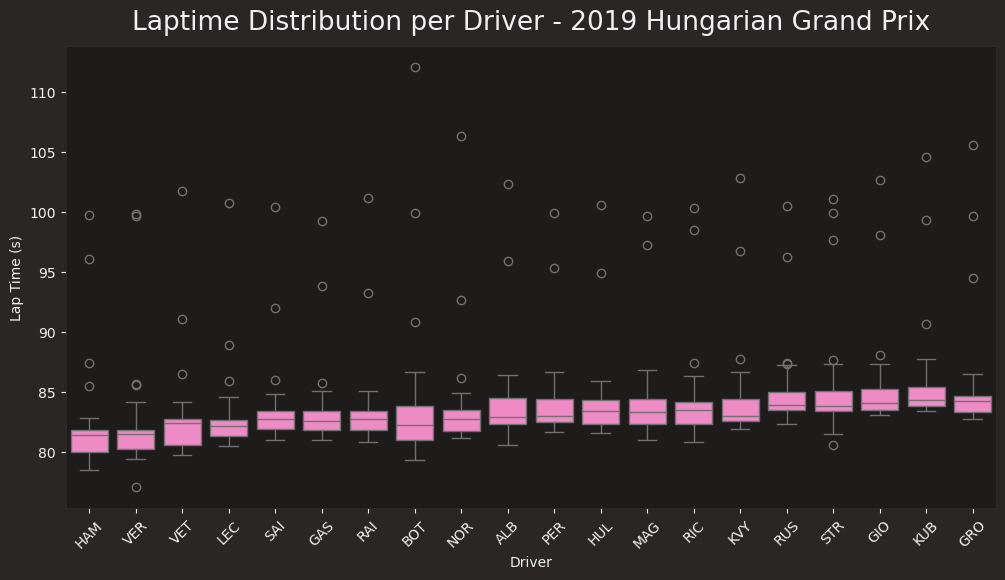

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_laps, x="Driver", y="LapTimeSeconds")

plt.ylabel("Lap Time (s)")
plt.title(f"Laptime Distribution per Driver - {session.event.year} {session.event.EventName}")
plt.xticks(rotation=45)

plt.show()

In [14]:
merged_df = df_laps.merge(
    df,
    on="DriverNumber",
    suffixes=("", "_result")
)

In [15]:
merged_df.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'Compound', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife',
       'Position', 'LapTimeSeconds', 'BroadcastName', 'Abbreviation',
       'TeamName', 'CountryCode', 'GridPosition', 'Position_result',
       'ClassifiedPosition', 'Time_result', 'Points', 'Status'],
      dtype='object')

In [16]:
merged_df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,Compound,SpeedI1,SpeedI2,SpeedFL,...,BroadcastName,Abbreviation,TeamName,CountryCode,GridPosition,Position_result,ClassifiedPosition,Time_result,Points,Status
0,0 days 00:34:16.691000,HAM,44,0 days 00:01:27.403000,1.0,1.0,MEDIUM,275.0,238.0,249.0,...,L HAMILTON,HAM,Mercedes,,3.0,1.0,1,0 days 01:35:03.796000,25.0,Finished
1,0 days 00:35:39.026000,HAM,44,0 days 00:01:22.335000,2.0,1.0,MEDIUM,273.0,239.0,248.0,...,L HAMILTON,HAM,Mercedes,,3.0,1.0,1,0 days 01:35:03.796000,25.0,Finished
2,0 days 00:37:00.972000,HAM,44,0 days 00:01:21.946000,3.0,1.0,MEDIUM,274.0,239.0,247.0,...,L HAMILTON,HAM,Mercedes,,3.0,1.0,1,0 days 01:35:03.796000,25.0,Finished
3,0 days 00:38:22.618000,HAM,44,0 days 00:01:21.646000,4.0,1.0,MEDIUM,271.0,241.0,247.0,...,L HAMILTON,HAM,Mercedes,,3.0,1.0,1,0 days 01:35:03.796000,25.0,Finished
4,0 days 00:39:44.385000,HAM,44,0 days 00:01:21.767000,5.0,1.0,MEDIUM,273.0,239.0,247.0,...,L HAMILTON,HAM,Mercedes,,3.0,1.0,1,0 days 01:35:03.796000,25.0,Finished


In [17]:
laptime = merged_df['LapTime']

merged_df['LapTimeSeconds'] = laptime.dt.total_seconds()

In [18]:
clean_laps = merged_df.pick_quicklaps()

In [19]:
q1 = clean_laps['LapTimeSeconds'].quantile(0.25)
q3 = clean_laps['LapTimeSeconds'].quantile(0.75)
iqr = q3 - q1

clean_laps = clean_laps[
    (clean_laps['LapTimeSeconds'] >= q1 - 1.5 * iqr) &
    (clean_laps['LapTimeSeconds'] <= q3 + 1.5 * iqr)
]

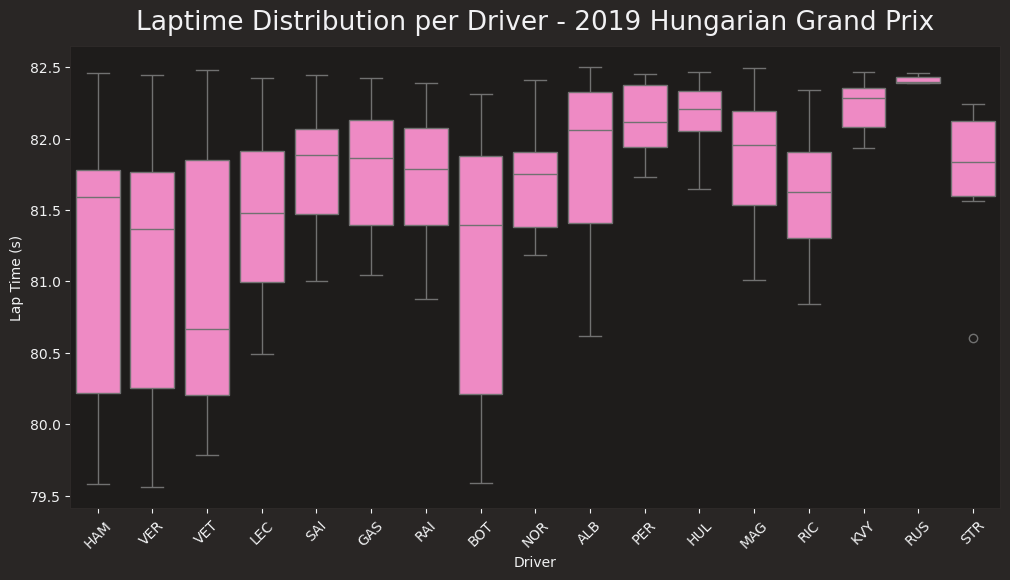

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=clean_laps, x="Driver", y="LapTimeSeconds")

plt.ylabel("Lap Time (s)")
plt.title(f"Laptime Distribution per Driver - {session.event.year} {session.event.EventName}")
plt.xticks(rotation=45)

plt.show()

In [21]:
clean_laps.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'Compound', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'TyreLife',
       'Position', 'LapTimeSeconds', 'BroadcastName', 'Abbreviation',
       'TeamName', 'CountryCode', 'GridPosition', 'Position_result',
       'ClassifiedPosition', 'Time_result', 'Points', 'Status'],
      dtype='object')

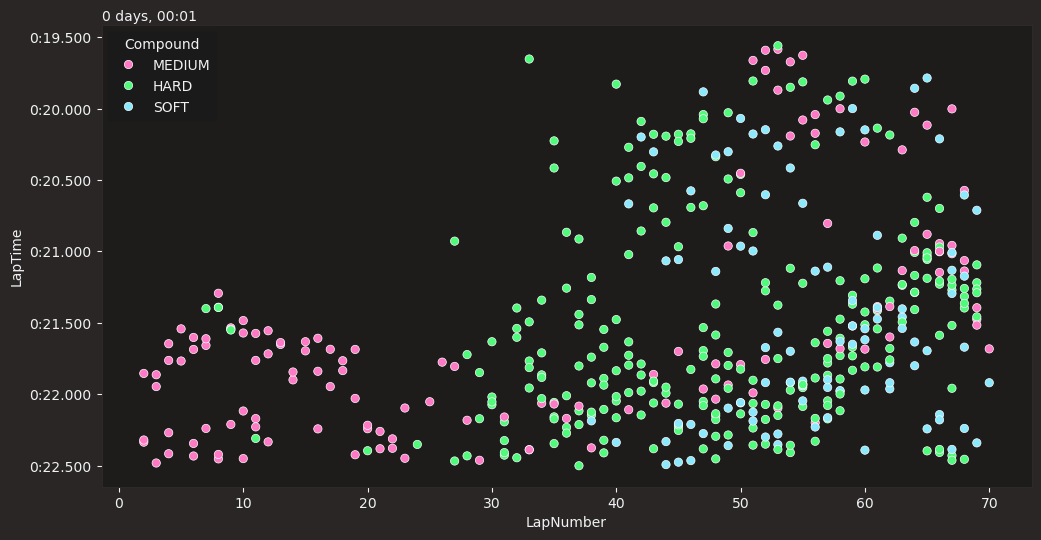

In [24]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=clean_laps, x='LapNumber', y='LapTime', hue='Compound')

plt.show()

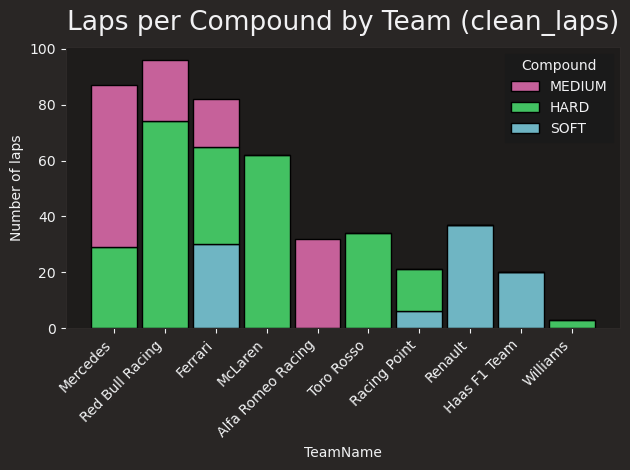

In [28]:
sns.histplot(
    data=clean_laps,
    x='TeamName',
    hue='Compound',
    multiple='stack',
    shrink=0.9
)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of laps')
plt.title('Laps per Compound by Team (clean_laps)')
plt.tight_layout()
plt.show()

C:\Users\pavel\AppData\Local\Temp\ipykernel_16824\4095909445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


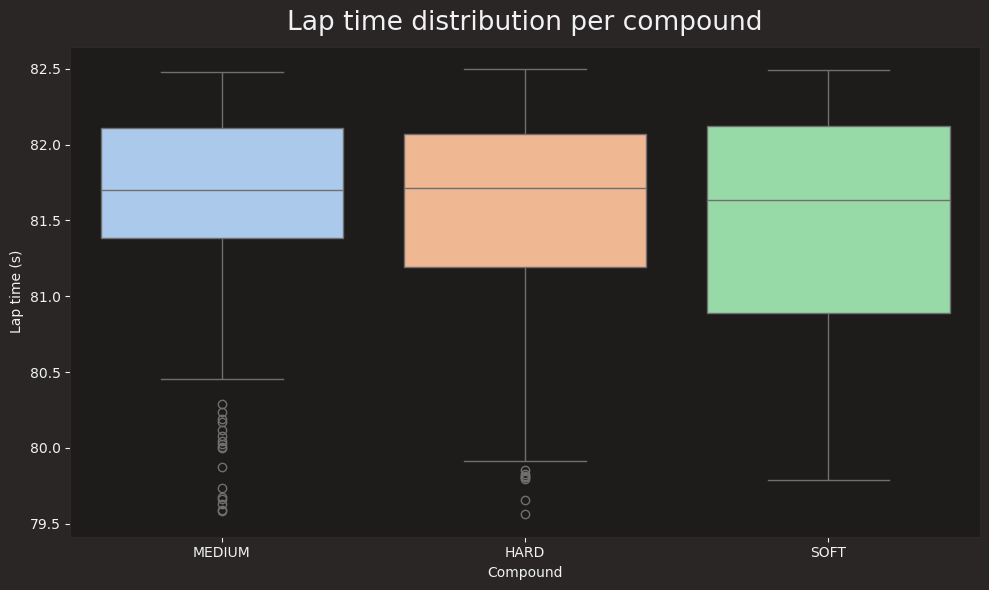

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=clean_laps,
    x='Compound',
    y='LapTimeSeconds',
    palette='pastel'
)
plt.ylabel('Lap time (s)')
plt.title('Lap time distribution per compound')
plt.tight_layout()
plt.show()

In [36]:
df = clean_laps[['Driver', 'GridPosition', 'ClassifiedPosition', 'Compound', 'TyreLife']].reset_index()

summary = (
    df.groupby(['Driver', 'Compound'])
      .agg(
          grid_start=('GridPosition', 'first'),
          finish_pos=('ClassifiedPosition', 'first'),
          avg_tyre_life=('TyreLife', 'mean'),
          lap_count=('Compound', 'size')
      )
      .reset_index()
)

summary

,Driver,Compound,grid_start,finish_pos,avg_tyre_life,lap_count
0,ALB,HARD,12.0,10,25.523810,21
1,BOT,HARD,2.0,8,25.142857,14
2,BOT,MEDIUM,2.0,8,12.476190,21
3,GAS,HARD,6.0,6,21.147059,34
4,HAM,HARD,3.0,1,9.933333,15
5,HAM,MEDIUM,3.0,1,16.513514,37
6,HUL,SOFT,11.0,12,18.210526,19
7,KVY,HARD,13.0,15,25.769231,13
8,LEC,HARD,4.0,4,22.628571,35
9,LEC,MEDIUM,4.0,4,11.875000,8


Compare Grid and Finish positions per driver and stint.
Insights about driver and tyre performance per driver, stint and teams.

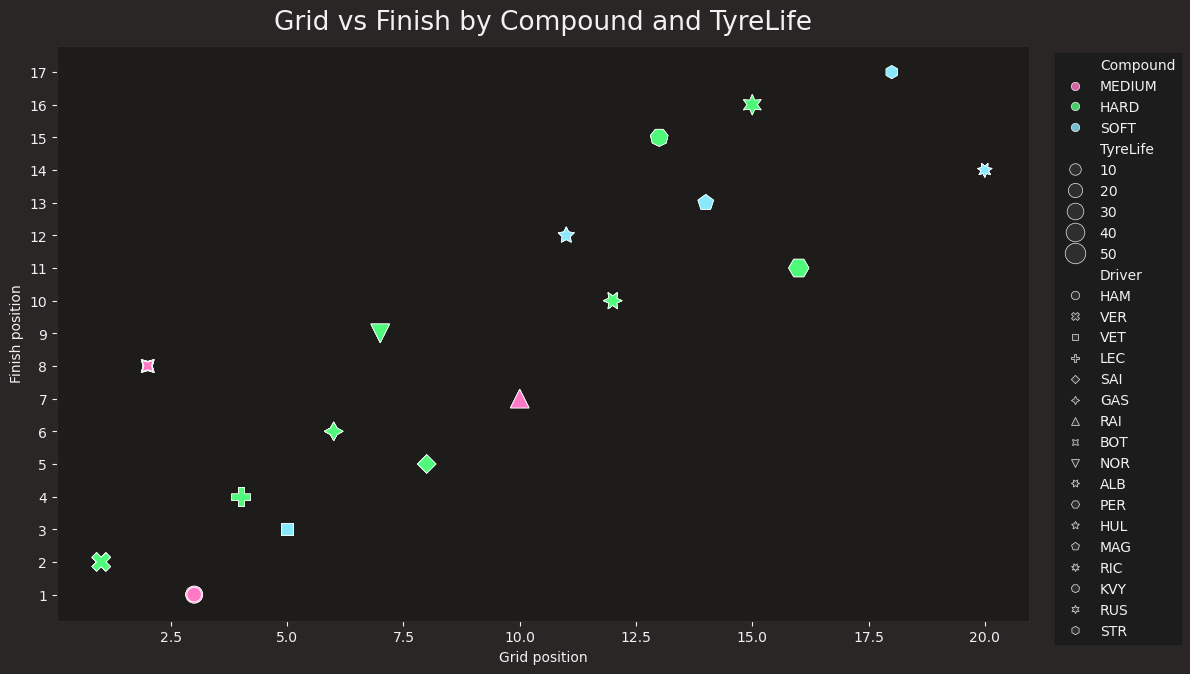

In [38]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x='GridPosition',
    y='ClassifiedPosition',
    hue='Compound',
    size='TyreLife',
    sizes=(40, 220),
    alpha=0.8,
    style='Driver'
)
plt.gca().invert_yaxis()   # optional: lower finish position at top
plt.xlabel('Grid position')
plt.ylabel('Finish position')
plt.title('Grid vs Finish by Compound and TyreLife')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

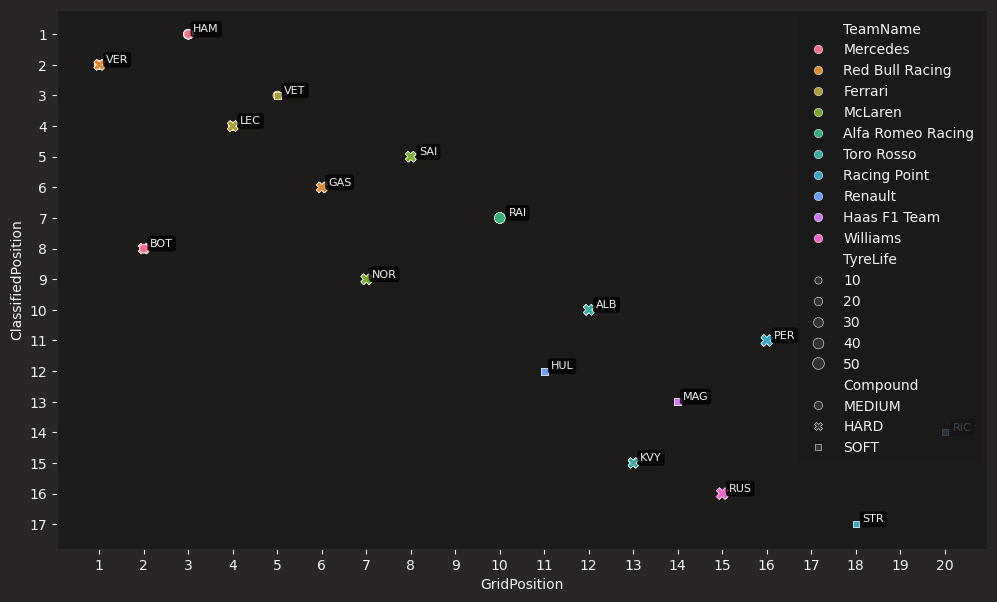

In [58]:
import numpy as np

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=clean_laps,
    x='GridPosition',
    y='ClassifiedPosition',
    hue='TeamName',
    style='Compound',
    size='TyreLife'
)

# Deduplicate to label each driver only once
unique_drivers = clean_laps.drop_duplicates(subset=['Driver'])


for i, row in unique_drivers.iterrows():
    plt.text(row['GridPosition'] + 0.4, 
             row['ClassifiedPosition'], 
             row['Driver'], 
             fontsize=8,
             ha='center',
             va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

plt.xticks(np.arange(clean_laps['GridPosition'].min(), clean_laps['GridPosition'].max() + 1, 1))

plt.show()

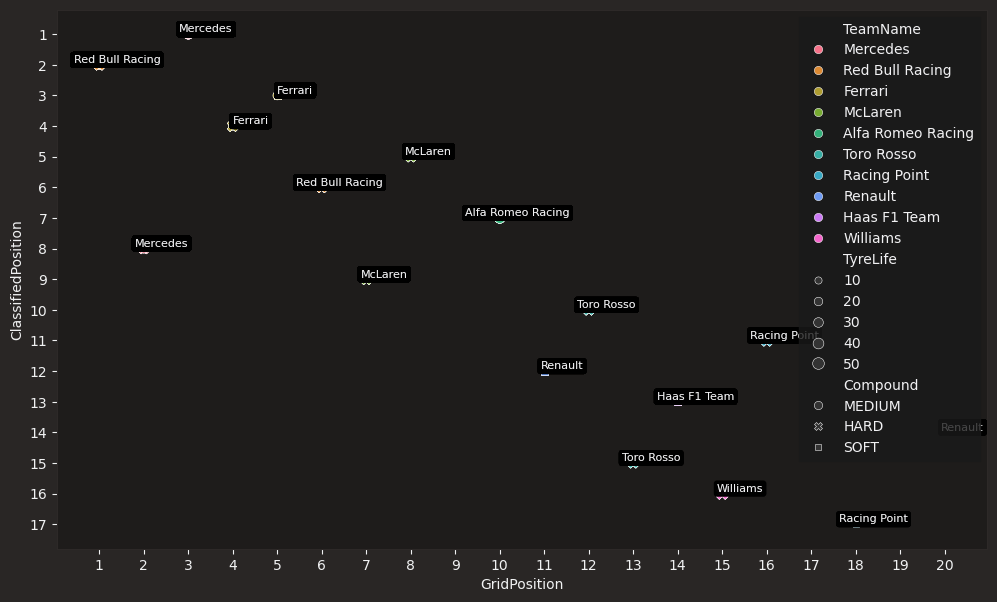

In [59]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=clean_laps,
    x='GridPosition',
    y='ClassifiedPosition',
    hue='TeamName',
    style='Compound',
    size='TyreLife'
)

# Deduplicate to label each driver only once
# unique_teams = clean_laps.drop_duplicates(subset=['Driver'])


for i, row in clean_laps.iterrows():
    plt.text(row['GridPosition'] + 0.4, 
             row['ClassifiedPosition'], 
             row['TeamName'], 
             fontsize=8,
             ha='center',
             va='bottom',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

plt.xticks(np.arange(clean_laps['GridPosition'].min(), clean_laps['GridPosition'].max() + 1, 1))

plt.show()

Positive/negative Grid-Finish relation per Driver and Compound.

In [65]:
performance_df = clean_laps[['Driver', 'TeamName', 'Compound', 'GridPosition', 'ClassifiedPosition', 'TyreLife']].copy()

In [70]:
clean_laps['ClassifiedPosition'] = clean_laps['ClassifiedPosition'].astype(float)

In [71]:
clean_laps.dtypes

Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
Compound                       object
SpeedI1                       float64
SpeedI2                       float64
SpeedFL                       float64
SpeedST                       float64
TyreLife                      float64
Position                      float64
LapTimeSeconds                float64
BroadcastName                  object
Abbreviation                   object
TeamName                       object
CountryCode                    object
GridPosition                  float64
Position_result               float64
ClassifiedPosition            float64
Time_result           timedelta64[ns]
Points                        float64
Status                         object
dtype: object

In [ ]:
# performance_df = clean_laps[['Driver', 'TeamName', 'Compound', 'GridPosition', 'ClassifiedPosition', 'TyreLife']].copy()
clean_laps['PositionChange'] = clean_laps['GridPosition'] - clean_laps['ClassifiedPosition']

In [75]:
df = clean_laps[['Driver', 'GridPosition', 'ClassifiedPosition', 'Compound', 'PositionChange', 'TyreLife']].reset_index()

summary = (
    df.groupby(['Driver', 'Compound'])
      .agg(
          grid_start=('GridPosition', 'first'),
          finish_pos=('ClassifiedPosition', 'first'),
          avg_tyre_life=('TyreLife', 'mean'),
          lap_count=('Compound', 'size'),
          position_gain_loss=('PositionChange', 'first')
      )
      .reset_index()
)

summary

,Driver,Compound,grid_start,finish_pos,avg_tyre_life,lap_count,position_gain_loss
0,ALB,HARD,12.0,10.0,25.523810,21,2.0
1,BOT,HARD,2.0,8.0,25.142857,14,-6.0
2,BOT,MEDIUM,2.0,8.0,12.476190,21,-6.0
3,GAS,HARD,6.0,6.0,21.147059,34,0.0
4,HAM,HARD,3.0,1.0,9.933333,15,2.0
5,HAM,MEDIUM,3.0,1.0,16.513514,37,2.0
6,HUL,SOFT,11.0,12.0,18.210526,19,-1.0
7,KVY,HARD,13.0,15.0,25.769231,13,-2.0
8,LEC,HARD,4.0,4.0,22.628571,35,0.0
9,LEC,MEDIUM,4.0,4.0,11.875000,8,0.0


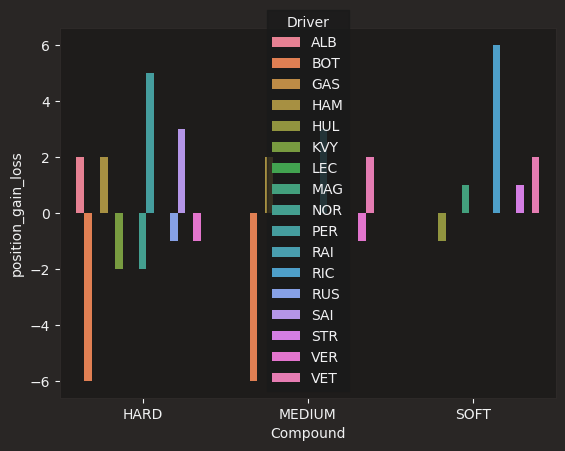

In [79]:
sns.barplot(
    data=summary,
    x='Compound',
    y='position_gain_loss',
    hue='Driver'
)
plt.show()